In [21]:
# pip install numpy-stl

# pip install git+https://github.com/cpederkoff/stl-to-voxel.git
# Command line:
# stltovoxel cube.stl cube.xyz
# stltovoxel cube.stl cube.npy

# pip install pyvista ipyvtklink pythreejs ipygany panel


In [31]:
import numpy as np
import pyvista as pv

surface = pv.read('cube.stl')

# print(surface)

cpos = [(7.656346967151718, -9.802071079151158, -11.021236183314311),
 (0.2224512272564101, -0.4594554282112895, 0.5549738359311297),
 (-0.6279216753504941, -0.7513057097368635, 0.20311105371647392)]

# surface.plot(cpos=cpos, opacity=0.75)

# surface.plot(color='lightgrey', pbr=True, metallic=0.2, jupyter_backend='pythreejs')
# surface.plot(cpos='xy', jupyter_backend='ipygany', show_scalar_bar=True)
# surface.plot(jupyter_backend='panel')


voxels = pv.voxelize(surface, density=surface.length/200)
voxels.plot(cpos=cpos, jupyter_backend='panel')
voxels

# p = pv.Plotter()
# p.add_mesh(voxels, color=True, show_edges=True, opacity=0.5)
# p.add_mesh(surface, color="lightblue", opacity=0.5)
# p.show(cpos=cpos)

# Scalar field
# voxels["density"] = np.full(voxels.n_cells, 3.65) # g/cc
# voxels.plot(scalars="density", cpos=cpos, jupyter_backend='panel')

# Scaled scalar field
# voxels.compute_implicit_distance(surface, inplace=True)
# voxels
# contours = voxels.contour(6, scalars="implicit_distance")
# p = pv.Plotter()
# p.add_mesh(voxels, opacity=0.25, scalars="implicit_distance")
# p.add_mesh(contours, opacity=0.5, scalars="implicit_distance")
# p.show(cpos=cpos)
# contours.plot(cpos=cpos, jupyter_backend='panel')


UnstructuredGrid (0x7efa35ce31c0)
  N Cells:	1520875
  N Points:	1560896
  X Bounds:	-1.000e+00, 9.919e-01
  Y Bounds:	-1.000e+00, 9.919e-01
  Z Bounds:	-1.000e+00, 9.919e-01
  N Arrays:	2

In [1]:
# Quickstart

import numpy as np
from stl import mesh

# Using an existing stl file:
# your_mesh = mesh.Mesh.from_file('car_dolly.stl')
your_mesh = mesh.Mesh.from_file('plug.stl')

# Or creating a new mesh (make sure not to overwrite the `mesh` import by
# naming it `mesh`):
VERTICE_COUNT = 100
data = np.zeros(VERTICE_COUNT, dtype=mesh.Mesh.dtype)
your_mesh = mesh.Mesh(data, remove_empty_areas=False)

# The mesh normals (calculated automatically)
your_mesh.normals
# The mesh vectors
your_mesh.v0, your_mesh.v1, your_mesh.v2
# Accessing individual points (concatenation of v0, v1 and v2 in triplets)
assert (your_mesh.points[0][0:3] == your_mesh.v0[0]).all()
assert (your_mesh.points[0][3:6] == your_mesh.v1[0]).all()
assert (your_mesh.points[0][6:9] == your_mesh.v2[0]).all()
assert (your_mesh.points[1][0:3] == your_mesh.v0[1]).all()

your_mesh.save('new_stl_file.stl')


exception (0, "Cannot read normals (2:b'a\\xe2\\xd3\\xb9a\\xac\\xea\\x8fa\\xde\\xf3\\x08a')")


exception (0, "Cannot read normals (2:b'fw?\\x85\\x88\\x84\\xbew\\x196;\\xeb\\x80\\x85d\\xad\\x04\\xe8c\\xaa\\xe8\\x98c\\xd0\\x82\\x85d\\x83\\x05\\xe8c\\xab\\xe8\\x8ec\\xa5\\x9a\\x85d\\xad\\x84\\xe9c\\x18\\xe9\\x98c')")


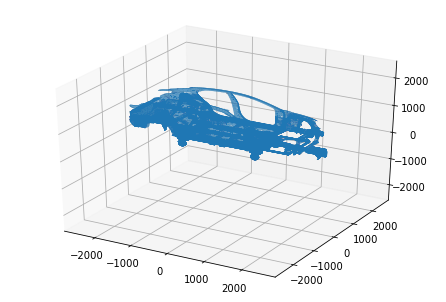

In [2]:
# Example plotting with Matplotlib

from stl import mesh
from mpl_toolkits import mplot3d
from matplotlib import pyplot

# Create a new plot
figure = pyplot.figure()
axes = mplot3d.Axes3D(figure)

# Load the STL files and add the vectors to the plot
# your_mesh = mesh.Mesh.from_file('plug.stl')
your_mesh = mesh.Mesh.from_file('car_dolly.stl')
axes.add_collection3d(mplot3d.art3d.Poly3DCollection(your_mesh.vectors))

# Auto scale to the mesh size
scale = your_mesh.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)

# Show the plot to the screen
pyplot.show()

exception (0, "Cannot read normals (2:b'a\\xe2\\xd3\\xb9a\\xac\\xea\\x8fa\\xde\\xf3\\x08a')")
(948, 3, 3)
float32


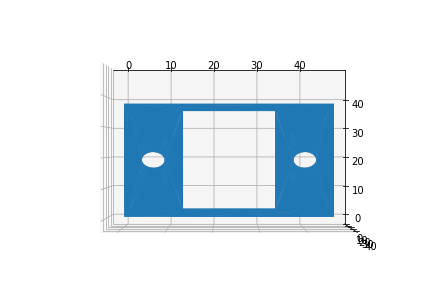

In [3]:
# import matplotlib as plt

mymesh = mesh.Mesh.from_file('plug.stl')

figure = pyplot.figure()
axes = mplot3d.Axes3D(figure)

axes.add_collection3d(mplot3d.art3d.Poly3DCollection(mymesh.vectors))
axes.view_init(90,270) # top view
scale = mymesh.points.flatten('F') #C, F, A, or K
axes.auto_scale_xyz(scale, scale, scale)

print(mymesh.vectors.shape)
print(mymesh.vectors.dtype)

pyplot.show()

float32 (470,)
float32 (470,)
float32 (470,)


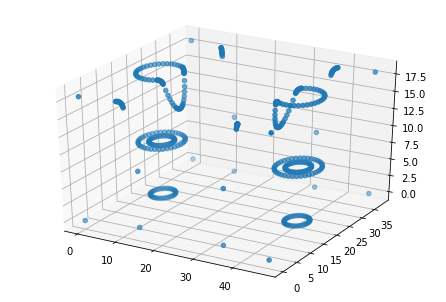

In [6]:
import numpy as np

vertices = mymesh.vectors.reshape(3*len(mymesh.vectors), 3)
vertices = np.unique(vertices, axis=0)
x, y, z = zip(*vertices)

print(np.asarray(x).dtype, np.asarray(x).shape)
print(np.asarray(y).dtype, np.asarray(y).shape)
print(np.asarray(z).dtype, np.asarray(z).shape)

figure = pyplot.figure()
axes = mplot3d.Axes3D(figure)
axes.scatter3D(x, y, z)
pyplot.show()

In [ ]:
# import trimesh
# mesh = trimesh.load_mesh('plug.stl')
# assert(mesh.is_watertight) # you cannot build a solid if your volume is not tight
# volume = mesh.voxelized(pitch=0.1)
# mat = volume.matrix # matrix of boolean

# mesh.contains(points)

In [ ]:
import numpy as np
import os
from stl import mesh
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import math


# if not os.getcwd() == 'path_to_model':
#     os.chdir('path_to model')


your_mesh = mesh.Mesh.from_file('plug.stl') #the stl file you want to voxelize


## set the height of your mesh
for i in range(len(your_mesh.vectors)):
    for j in range(len(your_mesh.vectors[i])):
        for k in range(len(your_mesh.vectors[i][j])):
            your_mesh.vectors[i][j][k] *= 5

## define functions
def triangle_voxalize(triangle):
    trix = []
    triy = []
    triz= []
    triangle = list(triangle)

    #corners of triangle in array formats
    p0 = np.array(triangle[0])
    p1 = np.array(triangle[1])
    p2 = np.array(triangle[2])

    #vectors and the plane of the triangle
    v0 = p1 - p0
    v1 = p2 - p1
    v2 = p0 - p2
    v3 = p2 - p0
    plane = np.cross(v0,v3)

    #minimun and maximun coordinates of the triangle
    for i in range(3):
        trix.append(triangle[i][0])
        triy.append(triangle[i][1])
        triz.append(triangle[i][2])
    minx, maxx = int(np.floor(np.min(trix))), int(np.ceil(np.max(trix)))
    miny, maxy = int(np.floor(np.min(triy))), int(np.ceil(np.max(triy)))
    minz, maxz = int(np.floor(np.min(triz))), int(np.ceil(np.max(triz)))

    #safe the points that are inside triangle
    points = []

    #go through each point in the box of minimum and maximum x,y,z
    for x in range (minx,maxx+1):
        for y in range(miny,maxy+1):
            for z in range(minz,maxz+1):

                #check the diagnals of each voxel cube if they are inside triangle
                if LinePlaneCollision(triangle,plane,p0,[1,1,1],[x-0.5,y-0.5,z-0.5],[x,y,z]):
                    points.append([x,y,z])
                elif LinePlaneCollision(triangle,plane,p0,[-1,-1,1],[x+0.5,y+0.5,z-0.5],[x,y,z]):
                    points.append([x,y,z])
                elif LinePlaneCollision(triangle,plane,p0,[-1,1,1],[x+0.5,y-0.5,z-0.5],[x,y,z]):
                    points.append([x,y,z])
                elif LinePlaneCollision(triangle,plane,p0,[1,-1,1],[x-0.5,y+0.5,z-0.5],[x,y,z]):
                    points.append([x,y,z])

                #check edge cases and if the triangle is completly inside the box
                elif intersect(triangle,[x,y,z],v0,p0):
                    points.append([x,y,z])
                elif intersect(triangle,[x,y,z],v1,p1):
                    points.append([x,y,z])
                elif intersect(triangle,[x,y,z],v2,p2):
                    points.append([x,y,z])

    #return the points that are inside the triangle
    return(points)

#check if the point is on the triangle border
def intersect(triangle,point,vector,origin):
    x,y,z = point[0],point[1],point[2]
    origin = np.array(origin)

    #check the x faces of the voxel point
    for xcube in range(x,x+2):
        xcube -= 0.5
        if LinePlaneCollision(triangle,[1,0,0], [xcube,y,z], vector, origin,[x,y,z]):
            return(True)

    #same for y and z
    for ycube in range(y,y+2):
        ycube -= 0.5
        if LinePlaneCollision(triangle,[0,1,0], [x,ycube,z], vector, origin,[x,y,z]):
            return(True)
    for zcube in range(z,z+2):
        zcube -= 0.5
        if LinePlaneCollision(triangle,[0,0,1], [x,y,zcube], vector, origin,[x,y,z]):
            return(True)

    #check if the point is inside the triangle (in case the whole tri is in the voxel point)
    if origin[0] <= x+0.5 and origin[0] >= x-0.5:
        if origin[1] <= y+0.5 and origin[1] >= y-0.5:
            if origin[2] <= z+0.5 and origin[2] >= z-0.5:
                return(True)

    return(False)

# I modified this file to suit my needs:
# https://gist.github.com/TimSC/8c25ca941d614bf48ebba6b473747d72
#check if the cube diagnals cross the triangle in the cube
def LinePlaneCollision(triangle,planeNormal, planePoint, rayDirection, rayPoint,point, epsilon=1e-6):
    planeNormal = np.array(planeNormal)
    planePoint = np.array(planePoint)
    rayDirection = np.array(rayDirection)
    rayPoint = np.array(rayPoint)


    ndotu = planeNormal.dot(rayDirection)
    if abs(ndotu) < epsilon:
        return(False)

    w = rayPoint - planePoint
    si = -planeNormal.dot(w) / ndotu
    Psi = w + si * rayDirection + planePoint

    #check if they cross inside the voxel cube
    if np.abs(Psi[0]-point[0]) <= 0.5 and np.abs(Psi[1]-point[1]) <= 0.5 and np.abs(Psi[2]-point[2]) <= 0.5:
        #check if the point is inside the triangle and not only on the plane
        if PointInTriangle(Psi, triangle):
            return (True)
    return (False)

# I used the following file for the next 2 functions, I converted them to python. Read the article. It explains everything way better than I can.
# https://blackpawn.com/texts/pointinpoly#:~:text=A%20common%20way%20to%20check,triangle%2C%20otherwise%20it%20is%20not.
#check if point is inside triangle
def SameSide(p1,p2, a,b):
    cp1 = np.cross(b-a, p1-a)
    cp2 = np.cross(b-a, p2-a)
    if np.dot(cp1, cp2) >= 0:
        return (True)
    return (False)

def PointInTriangle(p, triangle):
    a = triangle[0]
    b = triangle[1]
    c = triangle[2]
    if SameSide(p,a, b,c) and SameSide(p,b, a,c) and SameSide(p,c, a,b):
        return (True)
    return (False)

##
my_mesh = your_mesh.vectors.copy() #shorten the name

voxel = []
for i in range (len(my_mesh)): # go though each triangle and voxelize it
    new_voxel = triangle_voxalize(my_mesh[i])
    for j in new_voxel:
        if j not in voxel: #if the point is new add it to the voxel
            voxel.append(j)

##
print(len(voxel)) #number of points in the voxel

#split in x,y,z points
x_points = []
y_points = []
z_points = []
for a in range (len(voxel)):
    x_points.append(voxel[a][0])
    y_points.append(voxel[a][1])
    z_points.append(voxel[a][2])

## plot the voxel
ax = plt.axes(projection="3d")
ax.scatter3D(x_points, y_points, z_points)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## plot 1 layer of the voxel
for a in range (len(z_points)):
    if z_points[a] == 300:
        plt.scatter(x_points[a],y_points[a])

plt.show()

exception (0, "Cannot read normals (2:b'a\\xe2\\xd3\\xb9a\\xac\\xea\\x8fa\\xde\\xf3\\x08a')")


In [ ]:
from madcad.hashing import PositionMap
from madcad.io import read

# load the obj file in a madcad Mesh
mymesh = read('plug.stl')
# choose the cell size of the voxel
size = 1

voxel = set()    # this is a sparse voxel
hasher = PositionMap(size)   # ugly object creation, just to use one of its methods
for face in mymesh.faces:
    voxel.update(hasher.keysfor(mymesh.facepoints(face)))

# Print/Plot???

In [4]:
# import stl_reader
# import stltovoxel
# import numpy as np
# import copy
# import os
# import sys

# input = "plug.stl"
# output = "plug.xyz"
# resolution = 50 #Resolution, into how many layers the model should be divided
# stltovoxel.doExport(input, output, resolution)

In [ ]:
def point_cloud_to_volume(points, size=32):
    vol = np.zeros((size,size,size))
    locations = np.copy(points)
    locations[:] *= (size-1)
    locations = locations.astype(int)
    locations[locations >= size] = 0.0
    locations[locations < 0] = 0.0
    vol[locations[:,0],locations[:,1],locations[:,2]] = 1.0
    return vol

def vol2depthmap(volume_array, bg_val=32):
    vol = volume_array.argmax(2)
    vol[vol == 0] = bg_val
    return vol
v = point_cloud_to_volume(points)
%matplotlib inline
from matplotlib import pyplot as plt
plt.imshow(vol2depthmap(v), interpolation='nearest', cmap='Greys')
plt.colorbar()

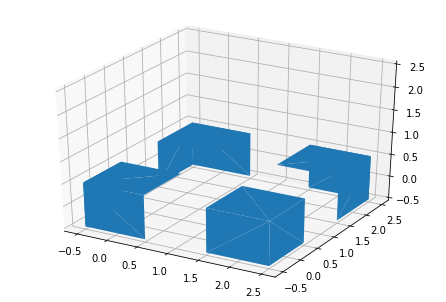

In [15]:
# Modifying Mesh objects

from stl import mesh
import math
import numpy as np

# Create 3 faces of a cube
data = np.zeros(6, dtype=mesh.Mesh.dtype)

# Top of the cube
data['vectors'][0] = np.array([[0, 1, 1],
                                  [1, 0, 1],
                                  [0, 0, 1]])
data['vectors'][1] = np.array([[1, 0, 1],
                                  [0, 1, 1],
                                  [1, 1, 1]])
# Front face
data['vectors'][2] = np.array([[1, 0, 0],
                                  [1, 0, 1],
                                  [1, 1, 0]])
data['vectors'][3] = np.array([[1, 1, 1],
                                  [1, 0, 1],
                                  [1, 1, 0]])
# Left face
data['vectors'][4] = np.array([[0, 0, 0],
                                  [1, 0, 0],
                                  [1, 0, 1]])
data['vectors'][5] = np.array([[0, 0, 0],
                                  [0, 0, 1],
                                  [1, 0, 1]])

# Since the cube faces are from 0 to 1 we can move it to the middle by
# substracting .5
data['vectors'] -= .5

# Generate 4 different meshes so we can rotate them later
meshes = [mesh.Mesh(data.copy()) for _ in range(4)]

# Rotate 90 degrees over the Y axis
meshes[0].rotate([0.0, 0.5, 0.0], math.radians(90))

# Translate 2 points over the X axis
meshes[1].x += 2

# Rotate 90 degrees over the X axis
meshes[2].rotate([0.5, 0.0, 0.0], math.radians(90))
# Translate 2 points over the X and Y points
meshes[2].x += 2
meshes[2].y += 2

# Rotate 90 degrees over the X and Y axis
meshes[3].rotate([0.5, 0.0, 0.0], math.radians(90))
meshes[3].rotate([0.0, 0.5, 0.0], math.radians(90))
# Translate 2 points over the Y axis
meshes[3].y += 2


# Optionally render the rotated cube faces
from matplotlib import pyplot
from mpl_toolkits import mplot3d

# Create a new plot
figure = pyplot.figure()
axes = mplot3d.Axes3D(figure)

# Render the cube faces
for m in meshes:
    axes.add_collection3d(mplot3d.art3d.Poly3DCollection(m.vectors))

# Auto scale to the mesh size
scale = np.concatenate([m.points for m in meshes]).flatten()
axes.auto_scale_xyz(scale, scale, scale)

# Show the plot to the screen
pyplot.show()

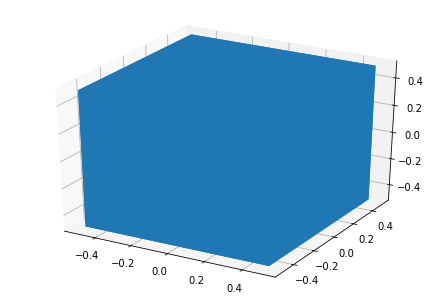

In [16]:
# Extending mesh objects

from stl import mesh
import math
import numpy as np

# Create 3 faces of a cube
data = np.zeros(6, dtype=mesh.Mesh.dtype)

# Top of the cube
data['vectors'][0] = np.array([[0, 1, 1],
                                  [1, 0, 1],
                                  [0, 0, 1]])
data['vectors'][1] = np.array([[1, 0, 1],
                                  [0, 1, 1],
                                  [1, 1, 1]])
# Front face
data['vectors'][2] = np.array([[1, 0, 0],
                                  [1, 0, 1],
                                  [1, 1, 0]])
data['vectors'][3] = np.array([[1, 1, 1],
                                  [1, 0, 1],
                                  [1, 1, 0]])
# Left face
data['vectors'][4] = np.array([[0, 0, 0],
                                  [1, 0, 0],
                                  [1, 0, 1]])
data['vectors'][5] = np.array([[0, 0, 0],
                                  [0, 0, 1],
                                  [1, 0, 1]])

# Since the cube faces are from 0 to 1 we can move it to the middle by
# substracting .5
data['vectors'] -= .5

cube_back = mesh.Mesh(data.copy())
cube_front = mesh.Mesh(data.copy())

# Rotate 90 degrees over the X axis followed by the Y axis followed by the
# X axis
cube_back.rotate([0.5, 0.0, 0.0], math.radians(90))
cube_back.rotate([0.0, 0.5, 0.0], math.radians(90))
cube_back.rotate([0.5, 0.0, 0.0], math.radians(90))

cube = mesh.Mesh(np.concatenate([
    cube_back.data.copy(),
    cube_front.data.copy(),
]))

# Optionally render the rotated cube faces
from matplotlib import pyplot
from mpl_toolkits import mplot3d

# Create a new plot
figure = pyplot.figure()
axes = mplot3d.Axes3D(figure)

# Render the cube
axes.add_collection3d(mplot3d.art3d.Poly3DCollection(cube.vectors))

# Auto scale to the mesh size
scale = cube_back.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)

# Show the plot to the screen
pyplot.show()

In [17]:
# Creating mesh objects from a list of vertices and faces

import numpy as np
from stl import mesh

# Define the 8 vertices of the cube
vertices = np.array([\
    [-1, -1, -1],
    [+1, -1, -1],
    [+1, +1, -1],
    [-1, +1, -1],
    [-1, -1, +1],
    [+1, -1, +1],
    [+1, +1, +1],
    [-1, +1, +1]])
# Define the 12 triangles composing the cube
faces = np.array([\
    [0,3,1],
    [1,3,2],
    [0,4,7],
    [0,7,3],
    [4,5,6],
    [4,6,7],
    [5,1,2],
    [5,2,6],
    [2,3,6],
    [3,7,6],
    [0,1,5],
    [0,5,4]])

# Create the mesh
cube = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))
for i, f in enumerate(faces):
    for j in range(3):
        cube.vectors[i][j] = vertices[f[j],:]

# Write the mesh to file "cube.stl"
cube.save('cube.stl')

In [19]:
# Evaluating Mesh properties (Volume, Center of gravity, Inertia)

import numpy as np
from stl import mesh

# Using an existing closed stl file:
your_mesh = mesh.Mesh.from_file('cube.stl')

volume, cog, inertia = your_mesh.get_mass_properties()
print("Volume                                  = {0}".format(volume))
print("Position of the center of gravity (COG) = {0}".format(cog))
print("Inertia matrix at expressed at the COG  = {0}".format(inertia[0,:]))
print("                                          {0}".format(inertia[1,:]))
print("                                          {0}".format(inertia[2,:]))


Volume                                  = 8.0
Position of the center of gravity (COG) = [0. 0. 0.]
Inertia matrix at expressed at the COG  = [ 5.33333333 -0.         -0.        ]
                                          [-0.          5.33333333 -0.        ]
                                          [-0.         -0.          5.33333333]


In [20]:
# Combining multiple STL files

import math
import stl
from stl import mesh
import numpy as np


# find the max dimensions, so we can know the bounding box, getting the height,
# width, length (because these are the step size)...
def find_mins_maxs(obj):
    minx = obj.x.min()
    maxx = obj.x.max()
    miny = obj.y.min()
    maxy = obj.y.max()
    minz = obj.z.min()
    maxz = obj.z.max()
    return minx, maxx, miny, maxy, minz, maxz


def translate(_solid, step, padding, multiplier, axis):
    if 'x' == axis:
        items = 0, 3, 6
    elif 'y' == axis:
        items = 1, 4, 7
    elif 'z' == axis:
        items = 2, 5, 8
    else:
        raise RuntimeError('Unknown axis %r, expected x, y or z' % axis)

    # _solid.points.shape == [:, ((x, y, z), (x, y, z), (x, y, z))]
    _solid.points[:, items] += (step * multiplier) + (padding * multiplier)


def copy_obj(obj, dims, num_rows, num_cols, num_layers):
    w, l, h = dims
    copies = []
    for layer in range(num_layers):
        for row in range(num_rows):
            for col in range(num_cols):
                # skip the position where original being copied is
                if row == 0 and col == 0 and layer == 0:
                    continue
                _copy = mesh.Mesh(obj.data.copy())
                # pad the space between objects by 10% of the dimension being
                # translated
                if col != 0:
                    translate(_copy, w, w / 10., col, 'x')
                if row != 0:
                    translate(_copy, l, l / 10., row, 'y')
                if layer != 0:
                    translate(_copy, h, h / 10., layer, 'z')
                copies.append(_copy)
    return copies

# Using an existing stl file:
main_body = mesh.Mesh.from_file('ball_and_socket_simplified_-_main_body.stl')

# rotate along Y
main_body.rotate([0.0, 0.5, 0.0], math.radians(90))

minx, maxx, miny, maxy, minz, maxz = find_mins_maxs(main_body)
w1 = maxx - minx
l1 = maxy - miny
h1 = maxz - minz
copies = copy_obj(main_body, (w1, l1, h1), 2, 2, 1)

# I wanted to add another related STL to the final STL
twist_lock = mesh.Mesh.from_file('ball_and_socket_simplified_-_twist_lock.stl')
minx, maxx, miny, maxy, minz, maxz = find_mins_maxs(twist_lock)
w2 = maxx - minx
l2 = maxy - miny
h2 = maxz - minz
translate(twist_lock, w1, w1 / 10., 3, 'x')
copies2 = copy_obj(twist_lock, (w2, l2, h2), 2, 2, 1)
combined = mesh.Mesh(np.concatenate([main_body.data, twist_lock.data] +
                                    [copy.data for copy in copies] +
                                    [copy.data for copy in copies2]))

combined.save('combined.stl', mode=stl.Mode.ASCII)  # save as ASCII

FileNotFoundError: [Errno 2] No such file or directory: 'ball_and_socket_simplified_-_main_body.stl'